In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms

In [34]:
base_img_path='/kaggle/input/datasets/shuvoalok/cityscapes/train/img'
img_cityscape_train=os.listdir('/kaggle/input/datasets/shuvoalok/cityscapes/train/img')[:2001]
img_cityscape=[os.path.join(base_img_path,img) for img in img_cityscape_train]

base_label_path='/kaggle/input/datasets/shuvoalok/cityscapes/train/label'
label_cityscape_train=os.listdir('/kaggle/input/datasets/shuvoalok/cityscapes/train/label')[:2001]
label_cityscape=[os.path.join(base_label_path,label) for label in label_cityscape_train]

In [33]:
import os 
img_path_train=os.listdir('/kaggle/input/datasets/gurazeez/gta5-segmentation/Training_Pairs')
print(img_path_train[0])
base_dir='/kaggle/input/datasets/gurazeez/gta5-segmentation/Training_Pairs'
img_train=[os.path.join(base_dir,item) for item in img_path_train]
print(img_train[0])

def train_split(img_train):
           img=Image.open(img_train)
           width,height=img.size
           half=width//2 
           image=img.crop((0,0,half,height))
           label=img.crop((half,0,width,height))

           return image,label 



01301.png
/kaggle/input/datasets/gurazeez/gta5-segmentation/Training_Pairs/01301.png


In [35]:
import numpy as np
from PIL import Image

CITYSCAPES_COLORS = {
    0:  (128, 64, 128),   # road
    1:  (244, 35, 232),   # sidewalk
    2:  (70, 70, 70),     # building
    3:  (102, 102, 156),  # wall
    4:  (190, 153, 153),  # fence
    5:  (153, 153, 153),  # pole
    6:  (250, 170, 30),   # traffic light
    7:  (220, 220, 0),    # traffic sign
    8:  (107, 142, 35),   # vegetation
    9:  (152, 251, 152),  # terrain
    10: (70, 130, 180),   # sky
    11: (220, 20, 60),    # person
    12: (255, 0, 0),      # rider
    13: (0, 0, 142),      # car
    14: (0, 0, 70),       # truck
    15: (0, 60, 100),     # bus
    16: (0, 80, 100),     # train
    17: (0, 0, 230),      # motorcycle
    18: (119, 11, 32),    # bicycle
}

def rgb_to_class_map(mask_rgb, color_dict):
    h, w, _ = mask_rgb.shape
    colors = np.array(list(color_dict.values()))
    class_ids = np.array(list(color_dict.keys()))
    
    pixels = mask_rgb.reshape(-1, 3).astype(np.int32)
   # print(pixels,pixels.shape)
    distances = np.linalg.norm(pixels[:, None, :] - colors[None, :, :], axis=2)
    #print(distances,distances.shape)
    nearest = np.argmin(distances, axis=1)
    #print(nearest,nearest.shape)
    
    class_map = class_ids[nearest].reshape(h, w)

    return class_map 

In [36]:

train_data_gta5=[]

for  img in img_train:
  image,label=train_split(img)
  arr_label=np.array(label)
  class_label=rgb_to_class_map(arr_label,CITYSCAPES_COLORS) 
  train_data_gta5.append((image,class_label))

In [37]:
cityscape_train=[]
for idx,label in enumerate(label_cityscape):
    label=Image.open(label)
    image=Image.open(img_cityscape[idx])
    arr_label=np.array(label)
    class_label=rgb_to_class_map(arr_label,CITYSCAPES_COLORS)
    cityscape_train.append((image,class_label))

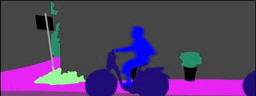

In [61]:
label=label_cityscape[0]
Image.open(label)

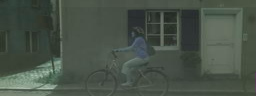

In [57]:
img,label=cityscape_train[0]
img

In [60]:
np.unique(label)

array([ 0,  1,  2,  3,  4,  5,  8,  9, 10, 13, 14, 15, 16, 17, 18])

In [38]:
class train_data(Dataset):
   def __init__(self,gta5_data,cityscape_data,transforms=None):
        self.gta5_data=gta5_data
        self.cityscape_data=cityscape_data
        self.transforms=transforms

   def __len__(self):
       return len(self.gta5_data)

   
   def __getitem__(self,idx):
       gta5_img,gta5_label=self.gta5_data[idx]
       cityscape_img,cityscape_label=self.cityscape_data[idx]
       
       if self.transforms:
           gta5_image = self.transforms(gta5_img)
           cityscape_image=self.transforms(cityscape_img)
        
       gta5_label=torch.from_numpy(gta5_label).long()
       cityscape_label=torch.from_numpy(cityscape_label).long()
       
       return gta5_image ,gta5_label ,cityscape_image , cityscape_label 

In [39]:
transforms=transforms.Compose([transforms.ToTensor(),transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])])

In [56]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [40]:
dataset=train_data(train_data_gta5,cityscape_train,transforms)

In [41]:
train_dataloader=DataLoader(dataset,32,shuffle=True)

In [42]:
class Encoder(nn.Module):
    def __init__(self,in_channel=3,out_channel=32,kernel_size=3,max_pool=2):
        super().__init__()
    
        
        # input 3 * 256 * 256 or 3 * 96 * 256   , out_channel = 32
        self.conv_block1=nn.Sequential(nn.Conv2d(in_channels=in_channel,out_channels=out_channel,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(out_channel),
                                       nn.ReLU(inplace=True),  # 32 * 256 * 256 , 32 * 96 * 256
                                       nn.Conv2d(in_channels=32,out_channels=32,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(32),
                                       nn.ReLU(inplace=True), # 32 * 256 * 256 , 32 * 96 * 256 
                                       nn.MaxPool2d(kernel_size=max_pool,stride=max_pool)) # 32 * 128* 128 , 32* 48*128
        
        self.conv_block2=nn.Sequential(nn.Conv2d(in_channels=32,out_channels=64,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(inplace=True), #64 *128*128 , 64 *48*128
                                       nn.Conv2d(in_channels=64,out_channels=64,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(inplace=True),  #64*128*128 , 64*48*128
                                       nn.MaxPool2d(kernel_size=max_pool,stride=max_pool)) #64 *64*64 , 64*24*64

        self.conv_block3=nn.Sequential(nn.Conv2d(in_channels=64,out_channels=128,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU(inplace=True),   #128 * 64*64,128*24*64
                                       nn.Conv2d(in_channels=128,out_channels=128,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU(inplace=True),   # 128*64*64 , 128*24*64
                                       nn.MaxPool2d(kernel_size=max_pool,stride=max_pool))  #128*32*32,128*12*32
        
        self.conv_block4=nn.Sequential(nn.Conv2d(in_channels=128,out_channels=256,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU(inplace=True),  # 256*32*32 , 256*12*32
                                       nn.Conv2d(in_channels=256,out_channels=256,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU(inplace=True), # 256*32*32 , 256*12*32
                                       nn.MaxPool2d(kernel_size=max_pool,stride=max_pool)) #256*16*16, 256*6*16

        self.conv_block5=nn.Sequential(nn.Conv2d(in_channels=256,out_channels=512,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU(inplace=True)) # 512*16*16 , 512*6*16

    
    def forward(self,input_img):
        # input : 3 * 256 * 256 , 3 * 96 * 256
        out1=self.conv_block1(input_img) # 32 * 128 *128 , 32 * 48 * 128 
        out2=self.conv_block2(out1)      # 64 * 64 * 64 , 64 * 24 * 64 
        out3=self.conv_block3(out2)      # 128 * 32 * 32  , 128 * 12 * 32 
        out4=self.conv_block4(out3)      # 256 * 16 * 16 , 256 * 6 *   16 
        bottleneck=self.conv_block5(out4) # 512 * 16 * 16 , 512 * 6 *  16

        return bottleneck ,[out1,out2,out3,out4]

In [43]:
class Generator_Unet(nn.Module):
    def __init__(self,in_channel=3,out_channel=32,kernel_size=3,max_pool=2,stride=2):
        super().__init__()

        self.encoder=Encoder(in_channel,out_channel,kernel_size,max_pool)

        # Decoder Part 
        self.upsample1=nn.Sequential(nn.ConvTranspose2d(in_channels=512,out_channels=512,kernel_size=1,stride=1))#512*16*16 , 512*6*16
        self.conv_block1=nn.Sequential(nn.Conv2d(in_channels=768,out_channels=384,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(384),
                                       nn.ReLU(inplace=True), # 384 * 16 * 16 , 384 * 6 * 16
                                       nn.Conv2d(in_channels=384,out_channels=384,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(384),
                                       nn.ReLU(inplace=True)) # 384 * 16 * 16 , 384 * 6 *16
        
        self.upsample2=nn.Sequential(nn.ConvTranspose2d(in_channels=384,out_channels=192,kernel_size=2,stride=2))#192*32*32,192*12*32
        self.conv_block2=nn.Sequential(nn.Conv2d(in_channels=320,out_channels=160,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(160),
                                       nn.ReLU(inplace=True), # 160*32*32 , 160 *12*32 
                                       nn.Conv2d(in_channels=160,out_channels=160,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(160),
                                       nn.ReLU(inplace=True)) # 160 * 32 *32 ,160 *12*32
        
        self.upsample3=nn.Sequential(nn.ConvTranspose2d(in_channels=160,out_channels=80,kernel_size=2,stride=2))# 80*64*64, 80*24*64
        self.conv_block3=nn.Sequential(nn.Conv2d(in_channels=144,out_channels=72,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(72),
                                       nn.ReLU(inplace=True), # 72*64*64 ,72*24*64
                                       nn.Conv2d(in_channels=72,out_channels=72,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(72),
                                       nn.ReLU(inplace=True) # 72 *64*64 , 72*24*64 
                                      )
        
        self.upsample4=nn.Sequential(nn.ConvTranspose2d(in_channels=72,out_channels=36,kernel_size=2,stride=2))#36 *128*128, 36*48*128
        self.conv_block4=nn.Sequential(nn.Conv2d(in_channels=68,out_channels=32,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(32),
                                       nn.ReLU(inplace=True),# 32*128*128 , 32*48*128
                                       nn.Conv2d(in_channels=32,out_channels=32,kernel_size=kernel_size,padding=1),
                                       nn.BatchNorm2d(32),
                                       nn.ReLU(inplace=True) # 32*128*128, 32*48*128
                                      )

        self.upsample5=nn.Sequential(nn.ConvTranspose2d(in_channels=32,out_channels=19,kernel_size=2,stride=2))#19*256*256,19*96*256

    def forward(self,input_img):
        bottleneck,encoder_list=self.encoder(input_img)
        o1,o2,o3,o4=encoder_list
        
        bottleneck_upsample=self.upsample1(bottleneck)
        s1=self.conv_block1(torch.cat([bottleneck_upsample,o4],dim=1))

        s1=self.upsample2(s1)
        s2=self.conv_block2(torch.cat([s1,o3],dim=1))

        s2=self.upsample3(s2)
        s3=self.conv_block3(torch.cat([s2,o2],dim=1))

        s3=self.upsample4(s3)
        s4=self.conv_block4(torch.cat([s3,o1],dim=1))

        output=self.upsample5(s4) # B * 1 * 256 * 256 
    

        return output

In [44]:
class Discriminator(nn.Module):
    def __init__(self,in_channel=19,out_channel=32,kernel_size=3,stride=2):
      super().__init__()

      # input : 19 * 256 * 256 , 19 * 96 * 256 
      self.conv_block1=nn.Sequential(nn.Conv2d(in_channels=in_channel,out_channels=out_channel,kernel_size=kernel_size,stride=stride,padding=1),
                                     nn.LeakyReLU(0.2,inplace=True))  # 32 * 128 * 128 , 32 * 48 * 128 

      self.conv_block2=nn.Sequential(nn.Conv2d(in_channels=out_channel,out_channels=64,kernel_size=kernel_size,stride=stride,padding=1),
                                     nn.BatchNorm2d(64),
                                     nn.LeakyReLU(0.2,inplace=True)) # 64 * 64 * 64 , 64 * 24 * 64 

      self.conv_block3=nn.Sequential(nn.Conv2d(in_channels=64 ,out_channels=128,kernel_size=kernel_size,stride=stride,padding=1),
                                     nn.BatchNorm2d(128),
                                     nn.LeakyReLU(0.2,inplace=True))  # 128 * 32 * 32 , 128 * 12 * 32

      self.conv_block4=nn.Sequential(nn.Conv2d(in_channels=128,out_channels=256,kernel_size=kernel_size,stride=stride,padding=1),
                                     nn.BatchNorm2d(256),
                                     nn.LeakyReLU(0.2,inplace=True))  # 256 * 16 * 16 , 256 * 6 * 16 

      self.conv_block5=nn.Sequential(nn.Conv2d(in_channels=256,out_channels=512,kernel_size=kernel_size,stride=stride,padding=1),
                                     nn.BatchNorm2d(512),
                                     nn.LeakyReLU(0.2,inplace=True)) # 512 * 8 * 8 , 512 * 3 * 8 

      self.adaptive_avg_pool=nn.AdaptiveAvgPool2d(1) # 512 * 1 * 1 , 512 * 1 * 1  
      self.fc=nn.Conv2d(in_channels=512,out_channels=1,kernel_size=1) # 1 * 1 * 1

    def forward(self,input_img):
        out=self.conv_block1(input_img)
        out=self.conv_block2(out)
        out=self.conv_block3(out)
        out=self.conv_block4(out)
        out=self.conv_block5(out)
        out=self.adaptive_avg_pool(out)
        out=self.fc(out)
        output=out.view(out.size(0),-1)

        return output
    

In [45]:
criterion_adv=nn.BCEWithLogitsLoss()
criterion_seg=nn.CrossEntropyLoss()

In [60]:
def generator_loss(gta5_seg,gta5_mask,cityscape_disc_pred):
    global criterion_seg , criterion_adv
    
    seg_loss=criterion_seg(gta5_seg,gta5_mask)
    adv_loss=criterion_adv(cityscape_disc_pred,torch.zeros_like(gta5_disc_pred))

    return seg_loss + adv_loss 


In [49]:
def discriminator_loss(gta5_disc_pred,cityscape_disc_pred):
    global  criterion_adv 

    fake_output=criterion_adv(gta5_disc_pred,torch.zeros_like(gta5_disc_pred))
    real_outpur=criterion_adv(cityscape_disc_pred,torch.ones_like(cityscape_disc_pred))

    return fake_output + real_output

In [58]:
generator_model=Generator_Unet().to(device)
generator_optimizer=optim.AdamW(generator_model.parameters(),lr=0.0001)

In [69]:
discriminator_model=Discriminator().to(device)
discriminator_optimizer=optim.AdamW(discriminator_model.parameters(),lr=0.0001)

In [70]:
def train_model(epochs,start_epoch=0):
    global train_dataloader,generator_model,generator_optimizer,discriminator_model,discriminator_optimizer,generator_loss,discriminator_loss,device,seg_criterion,adv_criterion
    generator_model.train()
    discriminator_model.train()
    for epoch in range(start_epoch,epochs+start_epoch):
        generator_total_loss,discriminator_total_loss=2*(0,)
        for idx,(gta5_image ,gta5_mask ,cityscape_image , cityscape_label) in enumerate(train_dataloader):

            gta5_image,gta5_mask,cityscape_image=gta5_image.to(device),gta5_mask.to(device),cityscape_image.to(device)
            gta5_seg=generator_model(gta5_image)
            cityscape_seg=generator_model(cityscape_image)


            discriminator_optimizer.zero_grad()
            cityscape_pred=discriminator_model(cityscape_seg.detach())
            gta5_pred=discriminator_model(gta5_image.detach())
            disc_loss=discriminator_loss(gta5_pred,cityscape_pred)
            discriminator_total_loss+=disc_loss.item()
            disc_loss.backward()
            discriminator_optimizer.step()
            
            generator_optmizier.zero_grad()
            cityscape_pred_gene=discriminator_model(cityscape_seg)
            gene_loss=generator_loss(gta5_seg,gta5_mask,cityscape_pred_gene)
            generator_total_loss+=gene_loss.item()
            gene_loss.backward()
            generator_optimizer.step()

        print(f'epoch :{epoch} ---> generator loss : {generator_total_loss/len(train_datakoader)} ---> discriminator loss :{discriminator_total_loss/len(train_datakoader)}')
        if (epoch+1)%10==0:
            torch.save({'epoch':epoch+1 , 'generator_state_dict':generator_model.state_dict(),'discriminator_state_dict':disriminator_model.state_dict(),'generator_optimizer':generator_optimizer.state_dict(),'discriminator_optimizer':discriminator_optimizer.state_dict()},f'checkpoint_{epoch+1}.pth')
    return generator_model , discriminator_model